In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("docker_stats.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit='s')

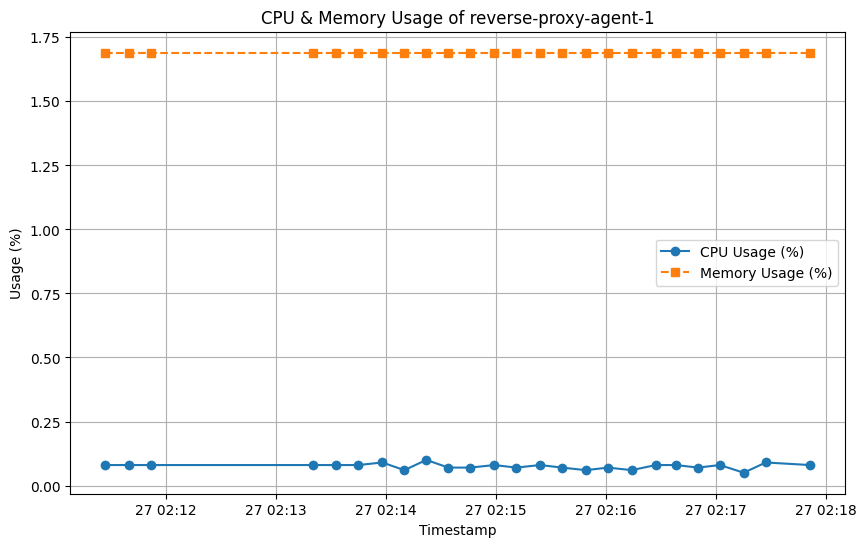

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("docker_stats.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit='s')

# 숫자 데이터 변환 (문자열 "%" 제거)
df["CPUPerc"] = df["CPUPerc"].str.replace("%", "").astype(float)
df["MemPerc"] = df["MemPerc"].str.replace("%", "").astype(float)

# 특정 컨테이너 선택 (예: reverse-proxy-agent-1)
container_name = "reverse-proxy-agent-1"
df_filtered = df[df["Name"] == container_name]

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(df_filtered["Timestamp"], df_filtered["CPUPerc"], marker='o', linestyle='-', label="CPU Usage (%)")
plt.plot(df_filtered["Timestamp"], df_filtered["MemPerc"], marker='s', linestyle='--', label="Memory Usage (%)")

# 그래프 설정
plt.xlabel("Timestamp")
plt.ylabel("Usage (%)")
plt.title(f"CPU & Memory Usage of {container_name}")
plt.legend()
plt.grid(True)

# 그래프 출력
plt.show()
